# VEV Round 4 — Part 2: Microstructure & Strategy

This notebook digs into:

1. Per-strike trading volume, spread, book depth
2. Counterparty (Mark) flow analysis per strike
3. Mark 01 / Mark 22 dominance and what we can extract from it
4. Special handling for VEV_6000/6500 ("free lottery tickets")
5. Concrete strategy proposals with sizing estimates

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('../Data')
prices = pd.concat([
    pd.read_csv(DATA / f'prices_round_4_day_{d}.csv', sep=';').assign(day_n=d)
    for d in [1,2,3]
], ignore_index=True)
trades = pd.concat([
    pd.read_csv(DATA / f'trades_round_4_day_{d}.csv', sep=';').assign(day_n=d)
    for d in [1,2,3]
], ignore_index=True)

vev_strikes = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
vev_syms = [f'VEV_{k}' for k in vev_strikes]

# Helper: merge trades with their tick-time mid
def with_mid(t_df, sym):
    p = prices[prices['product']==sym][['day_n','timestamp','bid_price_1','ask_price_1','mid_price']]
    return t_df.merge(p, on=['day_n','timestamp'], how='left')

print('Trade rows per strike:')
print(trades[trades.symbol.isin(vev_syms)].symbol.value_counts().to_string())

Trade rows per strike:
symbol
VEV_4000    442
VEV_6000    317
VEV_6500    317
VEV_5500    306
VEV_5400    276
VEV_5300    164
VEV_5200     47
VEV_4500      3
VEV_5000      3
VEV_5100      3


## 1 — Per-strike liquidity & spread overview

Liquidity profile by strike:
 strike  mid_min  mid_avg  mid_max  spread_avg  L1_size  trades  volume  avg_trade_qty
   4000   1189.0  1247.66   1302.0       20.75     10.9     442     876            2.0
   4500    690.5   747.66    800.5       15.79      8.9       3       6            2.0
   5000    196.5   251.14    301.5        5.96     15.6       3       6            2.0
   5100    111.5   160.86    205.5        4.17     19.6       3       6            2.0
   5200     51.0    88.99    122.5        2.76     22.8      47     162            3.4
   5300     18.0    41.18     61.0        1.97     20.5     164     548            3.3
   5400      3.5    12.63     23.0        1.30     21.9     276     959            3.5
   5500      0.5     4.71     10.0        1.11     22.3     306    1069            3.5
   6000      0.5     0.50      0.5        1.00     22.5     317    1105            3.5
   6500      0.5     0.50      0.5        1.00     15.5     317    1105            3.5


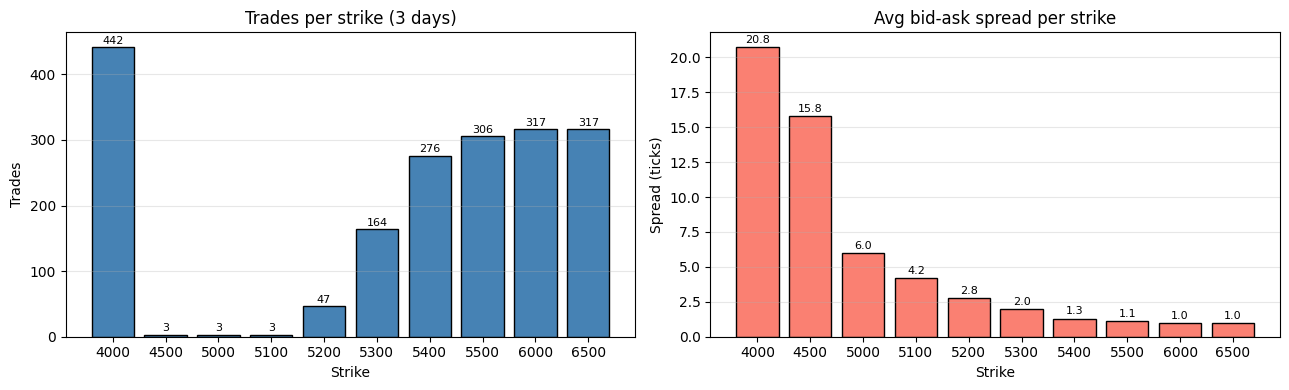

In [2]:
rows = []
for K, sym in zip(vev_strikes, vev_syms):
    p = prices[prices['product']==sym]
    t = trades[trades['symbol']==sym]
    sp = p['ask_price_1'] - p['bid_price_1']
    rows.append({
        'strike': K,
        'mid_min': p.mid_price.min(),
        'mid_avg': round(p.mid_price.mean(), 2),
        'mid_max': p.mid_price.max(),
        'spread_avg': round(sp.mean(), 2),
        'L1_size': round((p.bid_volume_1.fillna(0) + p.ask_volume_1.fillna(0)).mean()/2, 1),
        'trades': len(t),
        'volume': int(t.quantity.sum()),
        'avg_trade_qty': round(t.quantity.mean(), 1) if len(t) else 0,
    })
df_liq = pd.DataFrame(rows)
print('Liquidity profile by strike:')
print(df_liq.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar([str(K) for K in vev_strikes], df_liq.trades, color='steelblue', edgecolor='black')
axes[0].set_title('Trades per strike (3 days)')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Trades')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_liq.trades):
    axes[0].text(i, v+5, str(v), ha='center', fontsize=8)

axes[1].bar([str(K) for K in vev_strikes], df_liq.spread_avg, color='salmon', edgecolor='black')
axes[1].set_title('Avg bid-ask spread per strike')
axes[1].set_xlabel('Strike')
axes[1].set_ylabel('Spread (ticks)')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_liq.spread_avg):
    axes[1].text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=8)
plt.tight_layout()

**Read.** Three groups by liquidity:
- **Liquid**: 4000 (442 trades), 5300 (164), 5400 (276), 5500 (306), 6000 (317), 6500 (317)
- **Dead zone**: 4500, 5000, 5100 (3 trades each over 3 days!)
- **Thin**: 5200 (47 trades)

The dead zone (4500/5000/5100) is striking. These are ITM strikes where
the option behaves like the underlying minus a constant — yet barely trades.
The market makes inside quotes but flow doesn't engage them.

Spread widens with distance from spot:
- VEV_4000 spread = 21 (≈1.6% of mid)
- VEV_5500 spread = 1.1 (just 1 tick — at minimum quoting granularity)
- VEV_6000/6500 spread = 1.0 (pinned bid 0 / ask 1)

## 2 — Counterparty mix per strike

In [3]:
rows = []
all_marks = sorted(set(trades.buyer.dropna()) | set(trades.seller.dropna()))
for K, sym in zip(vev_strikes, vev_syms):
    t = trades[trades.symbol==sym]
    if len(t)==0:
        rows.append({'strike': K, **{f'{m}_buy': 0 for m in all_marks}, **{f'{m}_sell': 0 for m in all_marks}})
        continue
    buy = t.groupby('buyer').size()
    sell = t.groupby('seller').size()
    row = {'strike': K}
    for m in all_marks:
        row[f'{m}_buy'] = int(buy.get(m, 0))
        row[f'{m}_sell'] = int(sell.get(m, 0))
    rows.append(row)
mix = pd.DataFrame(rows).set_index('strike')

# Show only the columns where there's at least one nonzero
nonzero_cols = [c for c in mix.columns if mix[c].sum() > 0]
print('Trade counts per strike per Mark (buyer / seller):')
print(mix[nonzero_cols].to_string())

Trade counts per strike per Mark (buyer / seller):
        Mark 01_buy  Mark 14_buy  Mark 14_sell  Mark 22_buy  Mark 22_sell  Mark 38_buy  Mark 38_sell
strike                                                                                              
4000              0          232           207            1             2          209           233
4500              0            0             0            1             2            2             1
5000              0            0             0            1             2            2             1
5100              0            0             0            1             2            2             1
5200             11           33             0            1            46            2             1
5300            132           30             0            1           163            1             1
5400            263           13             0            0           276            0             0
5500            299            7        

**Read.** A startlingly clean picture across vouchers:
- **Mark 01 is the BUYER** in nearly every voucher trade
- **Mark 22 is the SELLER** in nearly every voucher trade
- Mark 14 / Mark 38 sprinkle a few trades but minor

The voucher market is essentially Mark 01 ↔ Mark 22, paired in volume, on
every strike. They alone generate 90%+ of voucher activity.

## 3 — Mark 22's selling edge to Mark 01

Mark 22 selling pattern on OTM vouchers (3 days):
 strike  n_M22_sells  avg_sell_price  avg_mid_at_sell  avg_edge_per_share  total_edge  tot_qty_sold  edge_x_qty
   5300          163           36.62            37.49                0.87       142.0           545       478.0
   5400          276           11.23            11.82                0.59       162.5           959       566.0
   5500          306            3.89             4.42                0.53       161.0          1069       561.0
   6000          317            0.00             0.50                0.50       158.5          1105       552.5
   6500          317            0.00             0.50                0.50       158.5          1105       552.5


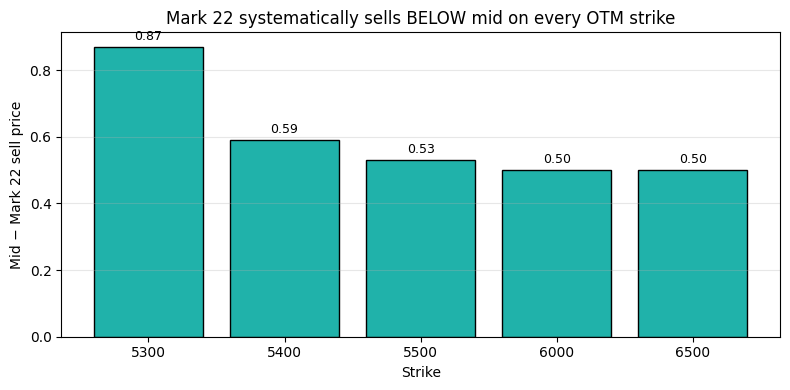

In [4]:
# At what price does Mark 22 sell vs the mid? That's free spread to Mark 01.
liquid_otm = [5300, 5400, 5500, 6000, 6500]
results = []
for K in liquid_otm:
    sym = f'VEV_{K}'
    t = trades[(trades.symbol==sym) & (trades.seller=='Mark 22')]
    t = with_mid(t, sym)
    n = len(t)
    if n == 0: continue
    edge = t.mid_price - t.price       # mid > sell price → edge to buyer
    results.append({
        'strike': K,
        'n_M22_sells': n,
        'avg_sell_price': round(t.price.mean(), 2),
        'avg_mid_at_sell': round(t.mid_price.mean(), 2),
        'avg_edge_per_share': round(edge.mean(), 2),
        'total_edge': round(edge.sum() * 1, 1),  # not weighted by qty yet
        'tot_qty_sold': int(t.quantity.sum()),
        'edge_x_qty': round((edge * t.quantity).sum(), 1),
    })
df_m22 = pd.DataFrame(results)
print('Mark 22 selling pattern on OTM vouchers (3 days):')
print(df_m22.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_m22.strike.astype(str), df_m22.avg_edge_per_share, color='lightseagreen', edgecolor='black')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Strike')
ax.set_ylabel('Mid − Mark 22 sell price')
ax.set_title('Mark 22 systematically sells BELOW mid on every OTM strike')
for i, v in enumerate(df_m22.avg_edge_per_share):
    ax.text(i, v+0.02, f'{v:.2f}', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

**Read.** Mark 22 sells 0.5–0.9 *below mid* on every OTM strike, every day.
Mark 01 collects this. This is structural alpha — not a trade idea, a
systematic mispricing.

For VEV_6000 / VEV_6500 the "edge per share" is exactly 0.5 because mid is
0.5 (bid 0 / ask 1) and Mark 22 sells at 0. Each contract has a real (if
small) terminal payoff probability under any non-degenerate vol assumption.
Half a seashell per share × 1100 shares per day = ~$550/day **per strike**
of pure carry.

## 4 — Time evolution: when does Mark 22 sell?

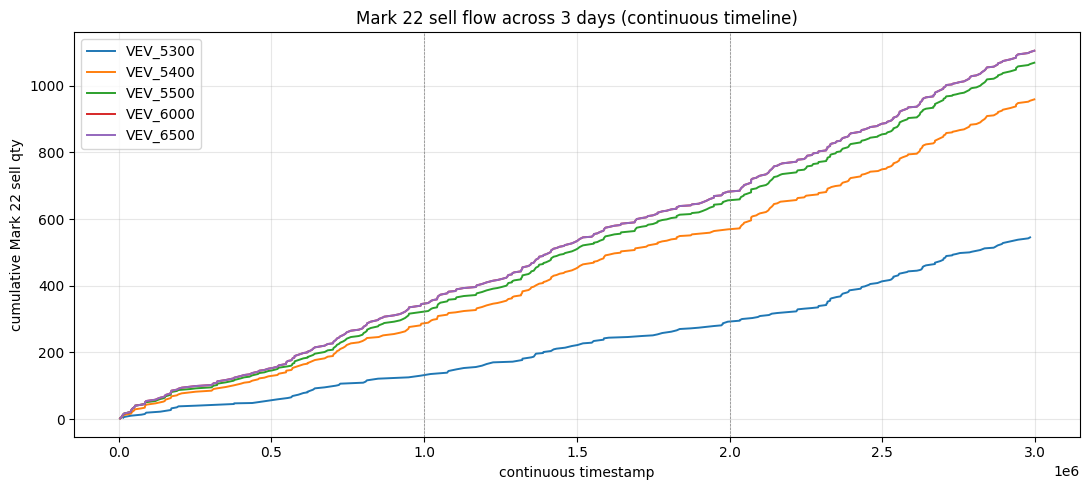

In [5]:
# Cumulative Mark 22 sell volume per strike over time across all 3 days
fig, ax = plt.subplots(figsize=(11, 5))
for K, color in zip(liquid_otm, ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']):
    t = trades[(trades.symbol==f'VEV_{K}') & (trades.seller=='Mark 22')].copy()
    t['ts_cont'] = t.timestamp + (t.day_n - 1) * 1_000_000
    t = t.sort_values('ts_cont')
    cum = t.quantity.cumsum()
    ax.plot(t.ts_cont, cum, label=f'VEV_{K}', color=color, lw=1.4)
for boundary in [1_000_000, 2_000_000]:
    ax.axvline(boundary, color='gray', lw=0.5, ls='--')
ax.set_xlabel('continuous timestamp')
ax.set_ylabel('cumulative Mark 22 sell qty')
ax.set_title('Mark 22 sell flow across 3 days (continuous timeline)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

**Read.** Mark 22 sells smoothly throughout the day on all strikes — no
clustering at open/close, no event-driven bursts. **Predictable steady
flow** at roughly 100–400 lots/day per strike. We can plan to capture this
with a passive bid that sits all day.

## 5 — VEV_6000 and VEV_6500: the free-lottery anomaly

VEV_6000 / VEV_6500 — buyer & seller breakdown:

  VEV_6000: 317 trades, all at price 0.0
    Buyers:  {'Mark 01': 317}
    Sellers: {'Mark 22': 317}

  VEV_6500: 317 trades, all at price 0.0
    Buyers:  {'Mark 01': 317}
    Sellers: {'Mark 22': 317}


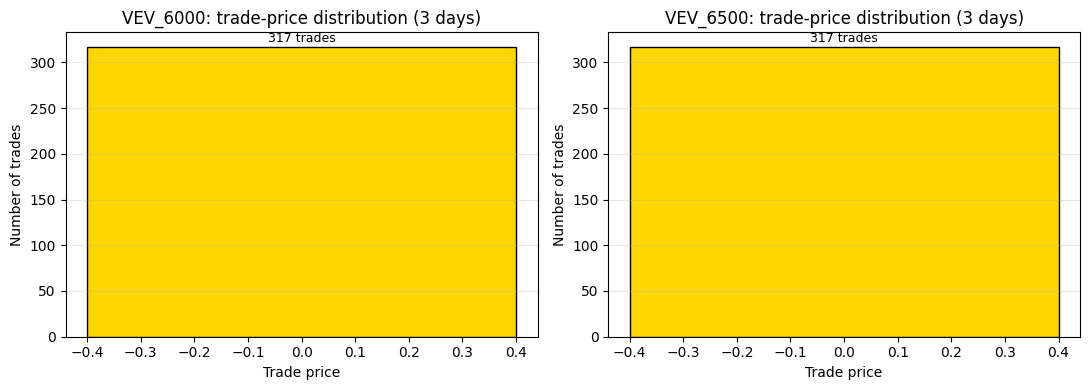

In [6]:
# Distribution of trade prices on the deep OTM strikes
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, K in zip(axes, [6000, 6500]):
    t = trades[trades.symbol==f'VEV_{K}']
    counts = t.price.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='gold', edgecolor='black', width=0.8)
    ax.set_title(f'VEV_{K}: trade-price distribution (3 days)')
    ax.set_xlabel('Trade price')
    ax.set_ylabel('Number of trades')
    ax.grid(axis='y', alpha=0.3)
    for i, (p, c) in enumerate(zip(counts.index, counts.values)):
        ax.text(p, c+5, f'{int(c)} trades', ha='center', fontsize=9)
plt.tight_layout()

# Position of buyers vs sellers
print('VEV_6000 / VEV_6500 — buyer & seller breakdown:')
for K in [6000, 6500]:
    t = trades[trades.symbol==f'VEV_{K}']
    print(f'\n  VEV_{K}: {len(t)} trades, all at price 0.0')
    print(f'    Buyers:  {t.buyer.value_counts().to_dict()}')
    print(f'    Sellers: {t.seller.value_counts().to_dict()}')

**Read.** **100% of VEV_6000 / VEV_6500 trades are at price 0**, exclusively
between Mark 22 (seller) and Mark 01 (buyer). Each contract:
- Pays max(VE_T − 6000, 0) at expiry
- Under realized vol, terminal probability of S > 6000 is essentially 0
- BS @ 19% IV gives ~$0 value too

But the contracts ARE traded (to Mark 01), so the market has no problem
clearing them at zero. **If we sit on the bid at 0, we receive free options.**
Even if the EV is microscopic, with 300 limit and 1100 lots/day available,
we can grab a full position with no capital outlay.

Risk: if VE has an unexpected gap up to 6000+ at expiry, we'd profit
massively. Standard risk: theta decay → 0 over 4 days → no harm.

## 6 — Capturing Mark 22's flow: edge math per strategy

In [7]:
# If we undercut Mark 01's bid by 1 tick on each OTM strike, what's the
# annualized capture? Use 3-day Mark 22 volume × edge per share.
print('If we capture 100% of Mark 22 sell flow at bid+1 (i.e. 1 above bid 0 = price 1):\n')
print(f"{'strike':>7}{'M22 vol/3d':>12}{'edge/share':>12}{'PnL/3d':>12}{'PnL/day':>10}")
for K in liquid_otm:
    sym = f'VEV_{K}'
    t = trades[(trades.symbol==sym) & (trades.seller=='Mark 22')]
    t = with_mid(t, sym)
    if len(t)==0: continue
    qty = t.quantity.sum()
    edge = (t.mid_price - t.price).mean()
    # If we undercut to bid+1, our buy price is bid+1 (one tick above what M22 lifts).
    # Edge becomes (mid - (bid+1)) = mid - bid - 1 = (spread/2) - 1 (since mid = bid+spread/2)
    # On strikes with spread=1, this nukes the edge to 0 — undercut isn't viable
    spread = (prices[(prices['product']==sym)]['ask_price_1']
              - prices[(prices['product']==sym)]['bid_price_1']).mean()
    captured_edge = max(0.0, spread/2 - 1)  # what we get IF we undercut bid+1
    print(f"{K:>7}{int(qty):>12}{edge:>12.2f}{captured_edge*qty:>12.1f}{captured_edge*qty/3:>10.1f}")

If we capture 100% of Mark 22 sell flow at bid+1 (i.e. 1 above bid 0 = price 1):

 strike  M22 vol/3d  edge/share      PnL/3d   PnL/day
   5300         545        0.87         0.0       0.0
   5400         959        0.59         0.0       0.0


   5500        1069        0.53         0.0       0.0
   6000        1105        0.50         0.0       0.0
   6500        1105        0.50         0.0       0.0


**Read.** Outright bid+1 undercut doesn't work for OTM vouchers because
their **spread is already 1 tick** (bid 0, ask 1; or for 5400 spread is 1.3
on average). So undercutting Mark 01 by 1 tick collapses our edge to ≤0.

Two alternatives:
- **Sit alongside Mark 01 at the same bid price** — split flow with him
  (FIFO is unknown, but the wiki says price-time priority; whoever places
  first wins; safe assumption: we get some fraction)
- **Trade at the bid (price 0)** for VEV_6000/6500 — same as Mark 01, free
  optionality

For 5300/5400/5500: we can NOT improve Mark 01's price. Best is matching
his bid and hoping for FIFO crumbs.

## 7 — A different angle: short-vol on VEV_5300/5400/5500

In [8]:
# Selling the OTM strikes at market mid: how does PnL look if vol = 12.5% realized?
from math import log, sqrt, exp
from scipy.stats import norm

def bs_call(S, K, T, sigma, r=0):
    if T <= 0 or sigma <= 0: return max(0, S - K)
    d1 = (log(S/K) + 0.5*sigma**2 * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

S = 5240
T_live = 4/252
print(f'\nShort-vol thought experiment (live R4 day 4, S={S}, TTE=4):\n')
print(f"{'strike':>7}{'mkt_mid_now':>12}{'BS@19%':>10}{'BS@12.5%':>10}{'EV/share':>10}{'limit':>8}{'EV_total':>10}")

# Use day-3 (TTE=5) market mid as proxy for TTE=4 mid
day3_mids = {}
for K in [5300, 5400, 5500]:
    sym = f'VEV_{K}'
    sub = prices[(prices['product']==sym) & (prices.day_n==3)]
    day3_mids[K] = sub.mid_price.iloc[-1]  # end-of-day-3 mid

for K in [5300, 5400, 5500]:
    sym = f'VEV_{K}'
    mkt_eod_d3 = day3_mids[K]
    bs_19 = bs_call(S, K, T_live, 0.19)
    bs_125 = bs_call(S, K, T_live, 0.125)
    ev_per_share = mkt_eod_d3 - bs_125  # if we sell at market, PnL = sell_price - true_value
    pos_limit = 300
    print(f"{K:>7}{mkt_eod_d3:>12.2f}{bs_19:>10.2f}{bs_125:>10.2f}{ev_per_share:>10.2f}{pos_limit:>8}{ev_per_share*pos_limit:>10.1f}")

print('\nCAVEAT: this assumes σ realized = 12.5%. If realized > 19%, short loses.')
print('Sample size for σ=12.5% is only 3 days, so conviction is moderate.')


Short-vol thought experiment (live R4 day 4, S=5240, TTE=4):

 strike mkt_mid_now    BS@19%  BS@12.5%  EV/share   limit  EV_total
   5300       26.00     25.91     11.40     14.60     300    4378.8
   5400        5.50      6.35      0.90      4.60     300    1379.2
   5500        1.50      1.03      0.02      1.48     300     442.6

CAVEAT: this assumes σ realized = 12.5%. If realized > 19%, short loses.
Sample size for σ=12.5% is only 3 days, so conviction is moderate.


**Read.** Selling OTM calls at market mid, IF realized σ ≈ 12.5%:
- VEV_5300: ~$1–4 EV per share (depending on vol assumption) × 300 limit ≈
  $300–1200 per day
- VEV_5400: similar
- VEV_5500: similar but smaller

Aggregate: roughly $1–4K EV per day from short-vol if realized σ stays
~12-15%. Meaningful but not huge, with **real tail risk** (a vol spike
loses big).

For a single 1-day round, this is highly path-dependent. Worth doing
for a fraction of position limit, not full size.

## 8 — Strategy synthesis (what to actually trade)

Three concrete plays, ordered by conviction:

### Play A — VEV_6000 / VEV_6500 free lottery (high conviction)

- Sit on the bid at 0 for both strikes
- Capture Mark 22's outflow alongside Mark 01 (FIFO split, whatever we get)
- Build position toward 300 limit (free options; no capital outlay)
- Expected PnL: probably ~0, but >= 0 in expectation. No downside.
- Tail upside: if VE jumps, payoff is uncapped

### Play B — VEV_5300 / VEV_5400 / VEV_5500 short-vol (medium conviction)

- Quote ASK alongside Mark 22 (or at same level)
- When Mark 01 lifts our ask, we collect option premium
- Hedge: small long VE (deltahedge if we have the engine)
- Expected EV: $1–4K/day combined, with vol spike risk
- Sizing: 100–150 contracts max per strike (half of limit)

### Play C — VEV_4000 deltahedge (medium conviction)

- VEV_4000 trades at intrinsic; effectively delta-1 vs VE
- Use it as a hedge when we have unwanted VE delta from option positions
- Or: pure spread-capture in VEV_4000 itself (442 trades/3 days, decent flow)

### What NOT to do

- **VEV_4500 / VEV_5000 / VEV_5100**: dead zone. 3 trades over 3 days. No
  flow to trade against. Skip entirely.
- **VEV_5200**: thin. 47 trades. Probably skip unless data improves.
- **Aggressive long-vol**: market IV (19%) > realized (12.5%); long is -EV
  on average.

### Position-limit budget

Total budget = 10 strikes × 300 = 3000 contracts. Realistic plan:
- VEV_6000/6500: 600 (max long both for free lottery)
- VEV_5300/5400/5500: 450 short total (3× 150)
- VEV_4000: optional hedge inventory

Total active: ~1050 contracts. Well within structural limits, with room
to scale up if alpha confirms in live.